<div style="border: 2px solid Deepskyblue; padding: 20px; border-radius: 10px; background-color: transparent; box-sizing: border-box; max-width: 98%; margin: 0 auto;">

<div style="position: relative;">

<img src="Unalm_logo.png" width="100" style="position:absolute; top:10px; right:10px;">

<center>

<h1 style="color:Deepskyblue; font-family:Georgia; font-weight:bold;">Variables Aleatorias Continuas Gamma</h1>

<h3 style="color:Gray; font-family:Georgia; font-style:italic; margin-top: -10px;">Diseño e Implementación: Programación Estructurada vs. POO</h3>
<br>

<p style="font-size:22px;"><b>Universidad Nacional Agraria La Molina</b></p>

<p style="font-size:18px;"><b>Departamento Académico de Economía y Planificación</b></p>



<p style="font-size:17px;"><b>Curso:</b> Lenguaje de Programación II</p>

<p style="font-size:17px;"><b>Docente:</b> Vargas Paredes, Ana C.</p>

<p style="font-size:17px;"><b>Grupo:</b> C</p>



<p style="font-size:17px;"><b>Ciclo:</b> 2026-I</p>

</center>

</div>

_____________________________

# 1. Introducción y Descripción del Caso

El presente trabajo tiene como objetivo diseñar e implementar bajo el enfoque de dos diferentes paradigmas de programación (PE y POO) diversas interacciones que se pueda hacer con variables aleatorias continuas, específicamente aquellas que pertenecen a la familia de distribuciones Gamma (incluyendo sus casos particulares: Exponencial y Ji-Cuadrado). La implementación debe permitir calcular a partir de los parámetros de las variables; la media, varianza, desviación estándar , obtener para un punto "$x$" su densidad $f(x)$ y su probabilidad acumulada $F(x)$, además de visualizar su distribución gráficamente y aplicar distintos teoremas matemáticos para la suma de variables aleatorias independientes. 

## Librerias a usar:

In [ ]:
#!pip install numpy matplotlib scipy
import math
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

________________________

# 2. Diseño del Caso

## Arquitectura y Planificación en Programación Estructurada (PE)

Para abordar el problema de simular variables aleatorias bajo este paradigma, la estrategia de diseño consiste en dividir el "gran problema" en tareas específicas cada vez más pequeñas. 

Como en PE no existe el concepto de "objeto" para encapsular información, se asume desde la etapa de planificación que los datos de las distribuciones (como `n`, `tasa`, `u` o `sigma`) deben vivir de forma independiente en el flujo principal del programa. Por lo tanto, el diseño plantea construir una "caja de herramientas" separada: un conjunto de funciones pasivas y estáticas preparadas para recibir esos parámetros explícitamente, realizar un cálculo específico y devolver un valor numérico.

Al planificar el módulo visual, se proyecta una característica típica del diseño Top-Down: **la interdependencia**. Para poder graficar, la rutina no operará de forma aislada; debe invocar internamente a las funciones matemáticas y apoyarse en estructuras de datos iterables (generando listas por comprensión) para procesar todos los puntos de los ejes X e Y antes de delegar el dibujo a la librería gráfica.

### Diagrama de Descomposición

En el siguiente esquema representamos cómo se ramifica el problema en submódulos, destacando especialmente el flujo interno proyectado para la rutina de visualización, la cual orquesta el uso de otras funciones matemáticas y el manejo de listas en memoria para lograr su objetivo:

```text
                                                 +--> [ Función ] calcular_media()
                                                 |
                                  +--> [ Sub ] --+--> [ Función ] calcular_varianza()
                                  |  (Cálculos)  |
                                  |              +--> [ Función ] calcular_ds()
                                  |              |
                                  |              +--> [ Función ] calcular_densidad(x)
                                  |              |
                                  |              +--> [ Función ] calcular_acumulada(x)
    [ Problema Principal ]        |
    (Simular Variables    ) ------+
    (Aleatorias Continuas )       |              +--> [ Función ] sumar_distribuciones()
                                  +--> [ Sub ] --+
                                  |  (Gestión)   +--> [ Variables ] (Paso de estado: parámetros sueltos)
                                  |
                                  |
                                  +--> [ Sub ] -----> [ Función ] graficar_distribucion()
                                     (Visualizar)       |
                                                        +--- [ Ejecuta ] --> calcular_media()
                                                        |
                                                        +--- [ Ejecuta ] --> calcular_ds()
                                                        |
                                                        +--- [ Memoria ] --> Crea [Lista X] con np.linspace
                                                        |
                                                        +--- [ Memoria ] --> Crea [Lista Y] iterando calcular_densidad()

## Arquitectura y Planificación en Programación Orientada a Objetos (POO)

En la fase de planificación bajo el paradigma Orientado a Objetos, el enfoque cambia radicalmente respecto a la programación estructurada: en lugar de pensar en "tareas sueltas", el objetivo es modelar la matemática como un ecosistema de **entidades** (objetos). De esta manera, cada distribución es dueña de su propio estado (sus parámetros) y de su propio comportamiento.

Esta estrategia de diseño nos permite estructurar la solución basándonos en cuatro pilares fundamentales:

* **Encapsulamiento como Protección:** Las clases se diseñan para ocultar sus parámetros matemáticos (`_n`, `_tasa`, `_u`, `_var`) como atributos privados. Así, el objeto "sabe" cómo calcular su propia media, varianza y cómo graficarse a sí mismo de manera autónoma, sin requerir que el flujo principal le inyecte dependencias constantemente.
* **Herencia para Eliminar Redundancia:** Dado que matemática y conceptualmente la distribución Exponencial y la Ji-Cuadrado son casos especiales de la Gamma, se establece una jerarquía de herencia directa. Esto evita reescribir toda la lógica de cálculo y visualización, heredándola directamente de la clase "madre".
* **Polimorfismo:** Se diseña e incorpora la clase `Normal`. Aunque esta clase **no hereda** de `Gamma` (porque sus parámetros base son estructuralmente distintos: $\mu$ y $\sigma^2$), se construye para que comparta exactamente la misma firma de métodos (`media()`, `varianza()`, `grafica_densidad()`). Esto garantiza que el sistema trate a todas las distribuciones por igual sin importar su origen.
* **Sobrecarga de Operadores como Puente (TLC):** Se redefine el método mágico `__add__` para representar algebraicamente el Teorema del Límite Central. Aquí es donde se conectan las clases independientes: si al sumar objetos `Gamma` el sistema detecta que $n \ge 30$, el método actúa como un patrón de fábrica y **retorna una nueva instancia de la clase `Normal`**, realizando la transición matemática y de tipo de dato de forma automática.

### Diagrama de Clases

En el siguiente esquema representamos nuestro diseño de clases. Destaca la jerarquía de herencia en la familia Gamma y la relación de dependencia (línea punteada) hacia la clase Normal, la cual se instancia dinámicamente cuando se cumple la condición matemática de la suma:

```text
                                               << Instancia (TLC) >>
+---------------------------------------+      Si n >= 30 en __add__      +---------------------------------------+
|                 Gamma                 | - - - - - - - - - - - - - - - ->|                Normal                 |
+---------------------------------------+                                 +---------------------------------------+
| - _n: float                           |                                 | - _u: float                           |
| - _tasa: float                        |                                 | - _var: float                         |
+---------------------------------------+                                 +---------------------------------------+
| + get_n(): float                      |                                 | + get_u(): float                      |
| + get_tasa(): float                   |                                 | + get_var(): float                    |
| + media(): float                      |                                 | + media(): float                      |
| + varianza(): float                   |                                 | + varianza(): float                   |
| + densidad(x: float): float           |                                 | + densidad(x: float): float           |
| + acumulada(x: float): float          |                                 | + acumulada(x: float): float          |
| + grafica_densidad()                  |                                 | + grafica_densidad()                  |
| + __add__(other: Gamma): Gamma/Normal |                                 | + __add__(other: Normal): Normal      |
| + __str__(): string                   |                                 | + __str__(): string                   |
+---------------------------------------+                                 +---------------------------------------+
          ^                   ^
          | hereda            | hereda
+-------------------+ +-------------------+
|    Exponencial    | |    Ji_Cuadrado    |
+-------------------+ +-------------------+
| + __init__(tasa)  | | + __init__(k)     |
| [Fija _n = 1]     | | [Fija n=k/2,      |
|                   | |  tasa=1/2]        |
+-------------------+ +-------------------+

____________________________

# 3. Implementación y Simulación del Caso

## 3.1. Paradigma de Programación Estructurada (PE)

### Distribución Gamma

* **Función de densidad:**

$$f(x) = \frac{\lambda^n x^{n-1} e^{-\lambda x}}{\Gamma(n)} I_{[0,\infty)}(x)$$

Donde:
* $n > 0$ es el **parámetro de forma**.
* $\lambda > 0$ es el **parámetro de tasa**.
* $\Gamma(n)$ es la función Gamma evaluada en $n$.
* $I_{[0,\infty)}(x)$ es la función indicadora con el rango de $X$.

* **Media:**
$$E[X] = \mu = \frac{n}{\lambda}$$

* **Varianza:**
$$V(X) = \sigma^2 = \frac{n}{\lambda^2}$$

In [51]:

# 1. Funciones de cálculo 
def media_Gamma(n, tasa):
    return n / tasa

def varianza_Gamma(n, tasa):
    return n / (tasa**2)

def ds_Gamma(n, tasa):
    return (varianza_Gamma(n, tasa))**(1/2)

def densidad_Gamma(n, tasa, x):
    if x > 0:
        numerador = (tasa**n) * (x**(n - 1)) * (math.exp(-tasa * x))
        denominador = math.gamma(n)
        fx = numerador / denominador
        return fx
    else:
        return 0

def acumulada_Gamma(n, tasa, x):
    if x > 0:
        escala = 1 / tasa
        Fx = round(stats.gamma.cdf(x, a = n, scale = escala).item(), 4)
        return Fx
    else: 
        return 0

In [52]:
# 2. Función de visualización
def grafica_densidad_Gamma(n, tasa):
    media = media_Gamma(n, tasa)
    sigma = ds_Gamma(n, tasa)
    rango_max = media * 4
    
    x = np.linspace(0, rango_max, 200)
    y = [densidad_Gamma(n, tasa, i) for i in x]
    
    plt.figure(figsize = (10, 5))
    plt.plot(x, y, label = f'Densidad Gamma', color='teal', linewidth=2)
    plt.fill_between(x, y, color='teal', alpha=0.15)
    
    plt.axvline(media, color = 'pink', linestyle = '--', linewidth = 1.5, label = f'Media ({round(media, 2)})')
    plt.axvline(media - sigma, color = 'pink', linestyle = ':', linewidth = 1, label = f'Media ± σ ({round(sigma, 2)})')
    plt.axvline(media + sigma, color = 'pink', linestyle = ':', linewidth = 1)
    
    plt.title(f"Distribución Gamma (n={n}, λ={tasa})")
    plt.xlabel("Valores de X")
    plt.ylabel("Densidad f(x)")
    plt.legend()
    plt.grid(True, linestyle = '--', alpha = 0.6)
    plt.show()

### Teorema: Suma de Variables Aleatorias Gamma Independientes

Sean $X_1, X_2, \dots, X_k$ variables aleatorias continuas independientes tales que:

$$X_i \sim \text{Gamma}(n_i, \lambda) \quad \text{para } i = 1, 2, \dots, k$$

Entonces, la suma de estas variables define una nueva variable aleatoria $Y$ que se distribuye de la siguiente manera:

$$Y = \sum_{i=1}^{k} X_i \sim \text{Gamma}\left( \sum_{i=1}^{k} n_i, \lambda \right)$$


### Aproximación de la Distribución Gamma a la Normal (TLC)

**1. Relación entre Exponencial y Gamma:**
Sea un conjunto de variables $X_1, X_2, \dots, X_n$ independientes e idénticamente distribuidas (i.i.d.) con distribución Exponencial, lo cual es equivalente a una distribución Gamma con parámetro de forma igual a 1:

$$X_i \sim \text{Exp}(\lambda) \equiv \text{Gamma}(1, \lambda)$$

La suma de estas $n$ variables exponenciales resulta en una distribución Gamma:

$$Y = \sum_{i=1}^{n} X_i \sim \text{Gamma}(n, \lambda)$$

**2. Teorema del Límite Central (para $n \ge 30$):**
Por el Teorema del Límite Central, si el número de variables sumadas ($n$) es lo suficientemente grande, la distribución de la suma $Y$ se aproxima a una distribución Normal:

$$Y \approx N(\mu_Y, \sigma_Y^2)$$

Donde los parámetros de la nueva distribución Normal son:

$$\mu_Y = n \cdot E[X_i] = \frac{n}{\lambda}$$

$$\sigma_Y^2 = n \cdot V(X_i) = \frac{n}{\lambda^2}$$

**Definición General Implementada:**
$$\text{Gamma}(n, \lambda) \xrightarrow{n \ge 30} N\left( n \cdot \mu_x, n \cdot \sigma^2_x \right)$$

In [53]:
# 3. Función de suma de variables
def sumar_distribuciones_Gamma(n1, tasa1, n2, tasa2):
    if tasa1 != tasa2:
        raise ValueError("Para sumar estas distribuciones, los parámetros de tasa deben ser iguales.")
    else: 
        nuevo_n = n1 + n2
        
        if nuevo_n < 30: 
            print(f"Parámetros de Gamma(n={nuevo_n}, λ={tasa1})")
            return nuevo_n, tasa1 
        else: 
            ux = media_Gamma(1, tasa1)
            u = nuevo_n * ux
            varx = varianza_Gamma(1, tasa1)
            var = nuevo_n * varx
            print(f"Parámetros de Normal(u={u}, σ²={var})")
            return u, var

### Distribución Exponencial

La distribución Exponencial es un caso particular de la familia Gamma. Se obtiene al fijar el parámetro de forma $n = 1$. Al sustituir $n=1$ en la función Gamma (recordando que $\Gamma(1) = 1$ y $x^0 = 1$), la ecuación se simplifica a:

* **Función de densidad:**

$$f(x) = \lambda e^{-\lambda x} I_{[0,\infty)}(x)$$

Donde:
* $\lambda > 0$ es el **parámetro de tasa**.
* $I_{[0,\infty)}(x)$ es la función indicadora con el rango de $X$.

* **Media:**
$$E[X] = \mu = \frac{1}{\lambda}$$

* **Varianza:**
$$V(X) = \sigma^2 = \frac{1}{\lambda^2}$$

In [54]:
# 1. Funciones de cálculo 
def media_Exponencial(tasa):
    return 1 / tasa

def varianza_Exponencial(tasa):
    return 1 / (tasa**2)

def ds_Exponencial(tasa):
    return (varianza_Exponencial(tasa))**(1/2)

def densidad_Exponencial(tasa, x):
    if x > 0:
        fx = (tasa) * (math.exp(-tasa * x)) 
        return fx
    else:
        return 0

def acumulada_Exponencial(tasa, x):
    if x > 0:
        Fx = round(1 - math.exp(-tasa * x), 4)
        return Fx
    else: 
        return 0

In [55]:
# 2. Función de visualización
def grafica_densidad_Exponencial(tasa):
    media = media_Exponencial(tasa)
    sigma = ds_Exponencial(tasa)
    rango_max = media * 4
    
    x = np.linspace(0, rango_max, 200)
    y = [densidad_Exponencial(tasa, i) for i in x]
    
    plt.figure(figsize = (10, 5))
    plt.plot(x, y, label = f'Densidad Exponencial', color='teal', linewidth=2)
    plt.fill_between(x, y, color='teal', alpha=0.15)
    
    plt.axvline(media, color = 'pink', linestyle = '--', linewidth = 1.5, label = f'Media ({round(media, 2)})')
    plt.axvline(media - sigma, color = 'pink', linestyle = ':', linewidth = 1, label = f'Media ± σ ({round(sigma, 2)})')
    plt.axvline(media + sigma, color = 'pink', linestyle = ':', linewidth = 1)
    
    plt.title(f"Distribución Exponencial (λ={tasa})")
    plt.xlabel("Valores de X")
    plt.ylabel("Densidad f(x)")
    plt.legend()
    plt.grid(True, linestyle = '--', alpha = 0.6)
    plt.show()

### Teorema: Suma de Variables Aleatorias Exponenciales Independientes

Como se definió previamente, una distribución Exponencial es equivalente a una distribución Gamma con parámetro de forma $n=1$. Por lo tanto, si tenemos dos variables aleatorias continuas independientes que siguen una distribución Exponencial con la misma tasa ($\lambda$):

$$X_1 \sim \text{Exp}(\lambda) \equiv \text{Gamma}(1, \lambda)$$
$$X_2 \sim \text{Exp}(\lambda) \equiv \text{Gamma}(1, \lambda)$$

La suma de ambas variables resulta en una nueva distribución que pertenece a la familia Gamma, con parámetro de forma $n = 1 + 1 = 2$:

$$Y = X_1 + X_2 \sim \text{Gamma}(2, \lambda)$$

In [56]:
# 3. Función de suma de variables
def sumar_distribuciones_Exponencial(tasa1, tasa2):
    if tasa1 != tasa2:
        raise ValueError("Para sumar estas distribuciones, los parámetros de tasa deben ser iguales.")
    else: 
        print(f"Parámetros de Gamma(n=2, λ={tasa1})")
        return 2, tasa1

### Distribución Ji-Cuadrado ($\chi^2$)

La distribución Ji-Cuadrado es otro caso particular de la familia Gamma. Se obtiene al fijar el parámetro de forma $n = k/2$ y el parámetro de tasa $\lambda = 1/2$, resultando en la siguiente simplificación:

* **Función de densidad:**

$$f(x) = \frac{x^{(k/2)-1} e^{-x/2}}{2^{k/2} \Gamma(k/2)} I_{[0,\infty)}(x)$$

Donde:
* $k > 0$ representa los **grados de libertad** (parámetro de la distribución).
* $\Gamma(k/2)$ es la función Gamma evaluada en $k/2$.
* $I_{[0,\infty)}(x)$ es la función indicadora con el rango de $X$.

* **Media:**
$$E[X] = \mu = k$$

* **Varianza:**
$$V(X) = \sigma^2 = 2k$$

In [57]:
# 1. Funciones de cálculo 
def media_JiCuadrado(k):
    return k

def varianza_JiCuadrado(k):
    return 2 * k

def ds_JiCuadrado(k):
    return (varianza_JiCuadrado(k))**(1/2)

def densidad_JiCuadrado(k, x):
    if x > 0:
        numerador = ((1/2)**(k/2)) * (x**((k/2) - 1)) * (math.exp(-(1/2) * x))
        denominador = math.gamma(k/2)
        fx = numerador / denominador
        return fx
    else:
        return 0

def acumulada_JiCuadrado(k, x):
    if x > 0:
        escala = 1 / (1/2)
        Fx = round(stats.gamma.cdf(x, a = k/2, scale = escala).item(), 4)
        return Fx
    else: 
        return 0

In [58]:
# 2. Función de visualización
def grafica_densidad_JiCuadrado(k):
    media = media_JiCuadrado(k)
    sigma = ds_JiCuadrado(k)
    rango_max = media * 4
    
    x = np.linspace(0, rango_max, 200)
    y = [densidad_JiCuadrado(k, i) for i in x]
    
    plt.figure(figsize = (10, 5))
    plt.plot(x, y, label = 'Densidad Ji-Cuadrado', color='teal', linewidth=2)
    plt.fill_between(x, y, color='teal', alpha=0.15)
    
    plt.axvline(media, color = 'pink', linestyle = '--', linewidth = 1.5, label = f'Media ({round(media, 2)})')
    plt.axvline(media - sigma, color = 'pink', linestyle = ':', linewidth = 1, label = f'Media ± σ ({round(sigma, 2)})')
    plt.axvline(media + sigma, color = 'pink', linestyle = ':', linewidth = 1)
    
    plt.title(f"Distribución Ji-Cuadrado (k={k})")
    plt.xlabel("Valores de X")
    plt.ylabel("Densidad f(x)")
    plt.legend()
    plt.grid(True, linestyle = '--', alpha = 0.6)
    plt.show()

### Teorema: Aditividad de la Distribución Ji-Cuadrado

Si tenemos $n$ variables aleatorias independientes $X_1, X_2, \dots, X_n$, tales que cada una sigue una distribución Ji-Cuadrado:

$$X_i \sim \chi^2(k_i) \quad \text{para } i = 1, 2, \dots, n$$

Entonces, la suma de estas variables también sigue una distribución Ji-Cuadrado, cuyos grados de libertad son la suma de los grados de libertad originales:

$$Y = \sum_{i=1}^{n} X_i \sim \chi^2\left( \sum_{i=1}^{n} k_i \right)$$

**Nota:** A diferencia de la distribución Gamma o Exponencial, la Ji-Cuadrado siempre se puede sumar sin restricciones adicionales, ya que todas comparten implícitamente el mismo parámetro de tasa ($\lambda = 1/2$).

### Aproximación de la Distribución Ji-Cuadrado a la Normal (TLC)

**1. Relación con la Normal Estándar:**
Una variable aleatoria Ji-Cuadrado con $k$ grados de libertad se define matemáticamente como la suma de los cuadrados de $k$ variables aleatorias independientes que siguen una distribución Normal Estándar ($Z_i \sim N(0,1)$):

$$Y = \sum_{i=1}^{k} Z_i^2 \sim \chi^2(k)$$

Dado que cada componente individual $Z_i^2$ equivale a una distribución $\chi^2(1)$, sabemos que $E[Z_i^2] = 1$ y $V(Z_i^2) = 2$.

**2. Teorema del Límite Central (para $k \ge 30$):**
Al ser $Y$ la suma de variables independientes e idénticamente distribuidas, el Teorema del Límite Central establece que para valores grandes de grados de libertad ($k \ge 30$), la distribución se aproxima a una Normal:

$$Y \approx N(\mu_Y, \sigma_Y^2)$$

Sustituyendo la media y la varianza de la suma de las componentes $Z_i^2$:

$$\mu_Y = k \cdot E[Z_i^2] = k$$
$$\sigma_Y^2 = k \cdot V(Z_i^2) = 2k$$

**Definición General Implementada:**
$$\chi^2(k) \xrightarrow{k \ge 30} N(k, 2k)$$

In [59]:
# 3. Función de suma de variables
def sumar_distribuciones_JiCuadrado(k1, k2):
    nuevo_k = k1 + k2
    
    if nuevo_k < 30: 
        print(f"Parámetros de Ji-Cuadrado(k={nuevo_k})")
        return nuevo_k 
    else: 
        # Sabemos que para k=1, la media es 1 y la varianza es 2
        ux = media_JiCuadrado(1) 
        u = nuevo_k * ux
        varx = varianza_JiCuadrado(1)
        var = nuevo_k * varx
        print(f"Parámetros de Normal(u={u}, σ²={var})")
        return u, var

### Distribución Normal

* **Función de densidad:**

$$f(x) = \frac{1}{\sigma \sqrt{2\pi}} e^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2}$$

Donde:
* $\mu \in \mathbb{R}$ es la **media**.
* $\sigma > 0$ es la **desviación estándar**.

* **Media:**
$$E[X] = \mu$$

* **Varianza:**
$$V(X) = \sigma^2$$

In [60]:
# 1. Funciones de cálculo 
def media_Normal(u, var):
    return u

def varianza_Normal(u, var):
    return var

def ds_Normal(u, var):
    return var**(1/2)

def densidad_Normal(u, var, x):
    numerador = math.exp(-0.5 * ((x - u)**2) / var)
    denominador = (2 * math.pi * var)**(1/2)
    fx = numerador / denominador
    return fx

def acumulada_Normal(u, var, x):
    Fx = round(stats.norm.cdf(x, loc=u, scale= (var)**(1/2)).item(), 4)
    return Fx

In [61]:
# 2. Función de visualización
def grafica_densidad_Normal(u, var):
    media = media_Normal(u, var)
    ds = ds_Normal(u, var)
    rango_min = media - (4 * ds)
    rango_max = media + (4 * ds)
    
    x = np.linspace(rango_min, rango_max, 200)
    y = [densidad_Normal(u, var, i) for i in x]
    
    plt.figure(figsize = (10, 5))
    plt.plot(x, y, label = 'Densidad Normal', color='deepskyblue', linewidth=2)
    plt.fill_between(x, y, color='deepskyblue', alpha=0.15)
    
    plt.axvline(media, color = 'darkorange', linestyle = '--', linewidth = 1.5, label = f'Media ({round(media, 2)})')
    plt.axvline(media - ds, color = 'darkorange', linestyle = ':', linewidth = 1, label = f'Media ± σ ({round(ds, 2)})')
    plt.axvline(media + ds, color = 'darkorange', linestyle = ':', linewidth = 1)
    
    plt.title(f"Distribución Normal (μ={u}, σ²={var})")
    plt.xlabel("Valores de X")
    plt.ylabel("Densidad f(x)")
    plt.legend()
    plt.grid(True, linestyle = '--', alpha = 0.6)
    plt.show()

### Teorema: Suma de Variables Aleatorias Normales Independientes

Una de las propiedades más importantes de la distribución Normal es que la suma de variables aleatorias Normales independientes siempre resulta en otra distribución Normal. 

Si tenemos dos variables aleatorias independientes $X_1$ y $X_2$, parametrizadas por su media ($\mu$) y su varianza ($\sigma^2$):

$$X_1 \sim N(\mu_1, \sigma_1^2) \quad \text{y} \quad X_2 \sim N(\mu_2, \sigma_2^2)$$

Entonces, la suma de estas variables define una nueva variable aleatoria $Y$ cuya distribución también es Normal. Los parámetros resultantes se obtienen sumando linealmente las medias y las varianzas originales:

$$Y = X_1 + X_2 \sim N(\mu_1 + \mu_2, \sigma_1^2 + \sigma_2^2)$$

In [62]:
# 3. Función de suma de variables
def sumar_distribuciones_Normal(u1, var1, u2, var2):
    nueva_u = u1 + u2
    nueva_var = (var1**2) + (var2**2)
    
    print(f"Parámetros de Normal(u={nueva_u}, σ^2={nueva_var})")
    return nueva_u, nueva_var

### Simulación de la Implementación

A continuación, ejecutamos las funciones implementadas para simular el comportamiento de variables aleatorias:
1. **Definición del estado inicial:** Inyección de parámetros.
2. **Cálculo de estadísticos y probabilidades:** Evaluación de la densidad y la probabilidad acumulada en un punto de interés ($x=4$).
3. **Visualización:** Generación de la gráfica de densidad.
4. **Transformación:** Aplicación del Teorema del Límite Central sumando dos distribuciones Gamma para obtener una aproximación Normal.

In [63]:
n_sim = 2
tasa_sim = 0.5
x_eval = 4

media_sim = media_Gamma(n_sim, tasa_sim)
var_sim = varianza_Gamma(n_sim, tasa_sim)
densidad_sim = densidad_Gamma(n_sim, tasa_sim, x_eval)
prob_acumulada_sim = acumulada_Gamma(n_sim, tasa_sim, x_eval)

print("--- SIMULACIÓN DE VARIABLE INDIVIDUAL ---")
print(f"Distribución : Gamma(n={n_sim}, λ={tasa_sim})")
print(f"Media (μ)    : {media_sim}")
print(f"Varianza (σ²): {var_sim}")
print(f"f(x={x_eval})      : {round(densidad_sim, 4)}")
print(f"F(x={x_eval})      : {prob_acumulada_sim}")
print("-" * 40)

--- SIMULACIÓN DE VARIABLE INDIVIDUAL ---
Distribución : Gamma(n=2, λ=0.5)
Media (μ)    : 4.0
Varianza (σ²): 8.0
f(x=4)      : 0.1353
F(x=4)      : 0.594
----------------------------------------


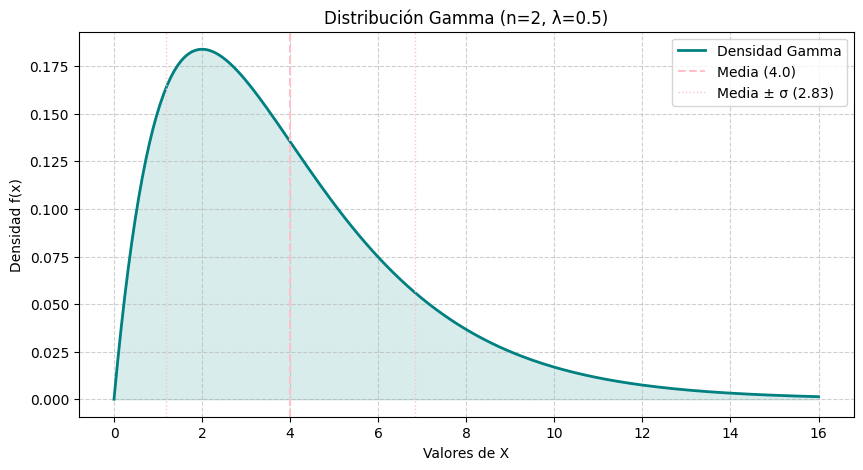

In [64]:
grafica_densidad_Gamma(n_sim, tasa_sim)


In [65]:
print("\n--- SIMULACIÓN DEL TEOREMA (SUMA Y TLC) ---")
n1 = 15
tasa1 = 0.5
n2 = 20
tasa2 = 0.5
print(f"Sumando Gamma(n={n1}, λ={tasa1}) + Gamma(n={n2}, λ={tasa2})")

parametros_nuevos = sumar_distribuciones_Gamma(n1, tasa1, n2, tasa2)


--- SIMULACIÓN DEL TEOREMA (SUMA Y TLC) ---
Sumando Gamma(n=15, λ=0.5) + Gamma(n=20, λ=0.5)
Parámetros de Normal(u=70.0, σ²=140.0)


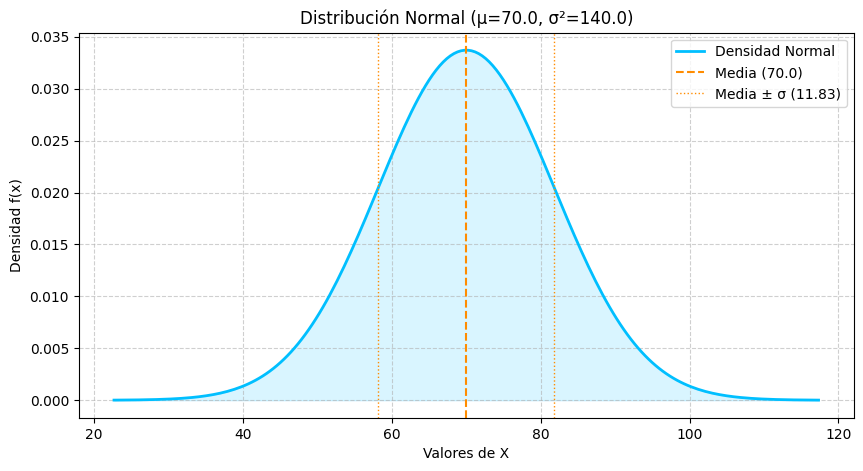

In [66]:
grafica_densidad_Normal(*parametros_nuevos)

## 3.2. Paradigma de Programación Orientada a Objetos (POO)

In [67]:
class Gamma():
    def __init__(self, n, tasa): # parámetro de forma, parámetro de tasa
        self._n = 1 # convención "_atributo"
        self._tasa = 1

        self.set_n(n)
        self.set_tasa(tasa)

    def get_n(self):
        return self._n
    def set_n(self, nuevon):
        if nuevon > 0:
            self._n = nuevon
        else:
            raise ValueError(f'El parámetro de forma "{nuevon}" no es válido, porque debe ser mayor a cero.')

    def get_tasa(self):
        return self._tasa
    def set_tasa(self, nuevatasa):
        if nuevatasa > 0:
            self._tasa = nuevatasa
        else:
            raise ValueError(f'El parámetro de tasa "{nuevatasa}" no es válida, porque debe ser mayor a cero.')

    def media(self):
        return self.get_n() / self.get_tasa()
    def varianza(self):
        return self.get_n() / (self.get_tasa())**2
    def desviacion_estandar(self):
        return (self.varianza())**(1/2)

    def __str__(self):
        return f'Gamma(n = {self.get_n()}, λ = {self.get_tasa()})'

    def __add__(self, other): 
        if isinstance(other, Gamma): # Retorna un booleano
            if self.get_tasa() == other.get_tasa():
                n = self.get_n() + other.get_n()
                tasa = self.get_tasa()
                if n < 30:
                    return Gamma(n, tasa)
                else:
                    return Normal(n * (1 / tasa), n * (1 / tasa**2))
            else:
                raise ValueError(f'Se requiere otra variable aleatoria "{type(self).__name__}" con mismo parámetro de tasa "{self.get_tasa()}".')
        else:
            raise TypeError(f'No se puede sumar una Gamma con un objeto de tipo "{type(other).__name__}", para cumplir con el Teorema.')

    def densidad(self, x):
        if x > 0:
            n = self.get_n()
            tasa = self.get_tasa()

            numerador = (tasa**n) * (x**(n - 1)) * (math.exp(-tasa * x))
            denominador = math.gamma(n)
            fx = numerador / denominador
            return fx
        else:
            return 0

    def grafica_densidad(self, rango_max = None, color = 'teal', color2 = 'darkorange'):
        if rango_max is None:
            rango_max = self.media() * 4 # Se espera que la media multiplicada x4 cubra casi todo el rango con densidad no despreciable.

        x = np.linspace(0, rango_max, 200) # lista con 200 puntos para x espaciados uniformemente entre 0 y rango_max.
        y = [self.densidad(i) for i in x] # Lista con 200 puntos para y en función de x.

        plt.figure(figsize=(10, 5)) # crea el lienzo para el gráfico, 10 unidades de ancho, 5 de alto.
        plt.plot(x, # Graficar linea (curva de la densidad).
                 y,
                 label = f"Densidad {type(self).__name__}",
                 color = color,
                 linewidth = 2)
        plt.fill_between(x, # Graficar área bajo la curva.
                         y,
                         color = color,
                         alpha = 0.15) # Nivel de transparencia.
        mu = self.media()
        sigma = self.desviacion_estandar()

        plt.axvline(mu, color = color2, linestyle='--', linewidth = 1.5, label=f'Media ({round(mu, 2)})') # Gráfica linea horizontal.
        plt.axvline(mu - sigma, color = color2, linestyle=':', linewidth = 1, label=f'Media ± σ ({round(sigma, 2)})')
        plt.axvline(mu + sigma, color = color2, linestyle=':', linewidth = 1)

        plt.title(f"Distribución {str(self)}") # Título.
        plt.xlabel("Valores de X") # Nombre del eje X.
        plt.ylabel("Densidad f(x)") # ombre del eje Y.
        plt.legend() # Cuadrito de densidad.
        plt.grid(True, # Gráfica cuadricula de fondo.
                 linestyle='--', # Tipo de linea para la cuadricula.
                 alpha=0.6) # Nivel de transparencia de las lineas.
        plt.show() # "print(gráfico)".
    
    def acumulada(self, x): # F(x) = P(X < x)
        if x > 0:
            n = self.get_n()
            escala = 1 / self.get_tasa()
            acumulada = stats.gamma.cdf(x, a = n, scale = escala).item() # tipo de dato parecido al float de python, .item() extrae el número sin etiqueta.
            return round(acumulada, 4)
        else:
            return 0

In [68]:
class Exponencial(Gamma):
    def __init__(self, tasa):
        if tasa > 0:
            self._tasa = tasa
        else:
            raise ValueError("La tasa debe ser mayor a cero")

        self._n = 1 # n siempre es 1 para la exponencial

    def set_n(self, nuevon): 
        if nuevon != 1:
            raise ValueError('No se puede cambiar el parámetro de forma, porque en una distribución Exponencial este siempre es 1.')

    def __str__(self):
        return f'Exponencial(tasa = {self.get_tasa()})'

In [69]:
class JiCuadrado(Gamma):
    def __init__(self, k):
        if k <= 0:
            raise ValueError(f'El parámetro de grados de libertad "{k}" no es válido, porque debe ser mayor a cero.')
        super().__init__(n = k /2, tasa = 1/2)

    def get_k(self):
        return self._n * 2
    def set_k(self, nuevok):
        if nuevok > 0:
            self._n = nuevok / 2
        else:
            raise ValueError(f'El parámetro de grados de libertad "{nuevok}" no es válido, porque debe ser mayor a cero.')

    def set_tasa(self, nuevatasa):
        if nuevatasa != 1/2:
            raise ValueError('No se puede cambiar el parámetro de tasa, porque en una distribución Ji Cuadrado este siempre es 1/2.')

    def __str__(self):
        return f'Ji Cuadrado(gl = {self.get_n() * 2})'

    def __add__(self, other): # suma de ji cuadrados
        if isinstance(other, JiCuadrado):
            k = self.get_k() + other.get_k()
            if k <= 30:
              return JiCuadrado(k)
            else:
              return Normal(k * 1, k * 2)
        else:
            raise TypeError(f'No se puede sumar una Ji Cuadrado con un objeto de tipo "{type(other).__name__}", para cumplir con el Teorema.')

In [70]:
class Normal():
    def __init__(self, u, var):
        self._u = 0 
        self._var = 1

        self.set_u(u)
        self.set_var(var)

    def get_u(self):
        return self._u
    def set_u(self, nuevau):
        self._u = nuevau

    def get_var(self):
        return self._var
    def set_var(self, nuevavar):
        if nuevavar > 0:
            self._var = nuevavar
        else:
            raise ValueError(f'El parámetro de varianza "{nuevavar}" no es válido, porque debe ser mayor a cero.')

    def media(self):
        return self.get_u()
    def varianza(self):
        return self.get_var()
    def desviacion_estandar(self):
        return (self.varianza())**(1/2)

    def __str__(self):
        return f'Normal(μ = {self.get_u()}, σ² = {self.get_var()})'

    def __add__(self, other):
        if isinstance(other, Normal):
            u = self.get_u() + other.get_u()
            var = self.get_var() + other.get_var()
            return Normal(u, var)
        else:
            raise TypeError(f'No se puede sumar una Normal con un objeto de tipo "{type(other).__name__}".')

    def densidad(self, x):
        u = self.get_u()
        sigma = self.desviacion_estandar()

        numerador = math.exp(-0.5 * ((x - u) / sigma)**2)
        denominador = sigma * math.sqrt(2 * math.pi)
        fx = numerador / denominador
        return fx

    def grafica_densidad(self, color = 'teal', color2 = 'darkorange'):
        mu = self.media()
        sigma = self.desviacion_estandar()
        
        rango_min = mu - (4 * sigma)
        rango_max = mu + (4 * sigma)

        x = np.linspace(rango_min, rango_max, 200)
        y = [self.densidad(i) for i in x]

        plt.figure(figsize=(10, 5))
        plt.plot(x,
                 y,
                 label = f"Densidad {type(self).__name__}",
                 color = color,
                 linewidth = 2)
        plt.fill_between(x,
                         y,
                         color = color,
                         alpha = 0.15)

        plt.axvline(mu, color = color2, linestyle='--', linewidth = 1.5, label=f'Media ({round(mu, 2)})')
        plt.axvline(mu - sigma, color = color2, linestyle=':', linewidth = 1, label=f'Media ± σ ({round(sigma, 2)})')
        plt.axvline(mu + sigma, color = color2, linestyle=':', linewidth = 1)

        plt.title(f"Distribución {str(self)}")
        plt.xlabel("Valores de X")
        plt.ylabel("Densidad f(x)")
        plt.legend()
        plt.grid(True,
                 linestyle='--',
                 alpha=0.6)
        plt.show()

    def acumulada(self, x):
        u = self.get_u()
        sigma = self.desviacion_estandar()
        Fx = stats.norm.cdf(x, loc = u, scale = sigma).item()
        return round(Fx, 4)

### Simulación del Modelo (Paradigma Orientado a Objetos)

A continuación, ejecutamos e interactuamos con las instancias de nuestras clases para simular el comportamiento de las variables aleatorias, evidenciando las ventajas arquitectónicas de la POO:

1. **Encapsulamiento:** Validación y protección del estado interno de los objetos, demostrando el manejo de excepciones ante parámetros matemáticamente inválidos.
2. **Abstracción y Sobrecarga (TLC):** Concatenación intuitiva de variables independientes utilizando el operador suma (`+`). Esto desencadena la transición automática de objetos Ji-Cuadrado hacia una distribución Normal cuando se cumplen las condiciones del Teorema del Límite Central.
3. **Polimorfismo:** Agrupación de clases matemáticas distintas (`Exponencial`, `Ji-Cuadrado`, `Normal`) en una misma estructura de datos, evaluando sus estadísticos mediante una interfaz uniforme y sin recurrir a estructuras condicionales.
4. **Visualización:** Envío de mensajes polimórficos para generar la gráfica de densidad de la variable resultante, delegando al objeto la responsabilidad de saber cómo dibujarse a sí mismo.

In [71]:
print("--- 1. ENCAPSULAMIENTO (Protección del estado interno) ---")
chi_prueba = JiCuadrado(5)
try:
    chi_prueba.set_k(-3) # Intentamos forzar grados de libertad negativos
except ValueError as e:
    print(f"Excepción capturada correctamente: {e}")

--- 1. ENCAPSULAMIENTO (Protección del estado interno) ---
Excepción capturada correctamente: El parámetro de grados de libertad "-3" no es válido, porque debe ser mayor a cero.


In [72]:
print("\n--- 2. ABSTRACCIÓN Y SOBRECARGA DE OPERADORES (TLC) ---")
chi1 = JiCuadrado(10)
chi2 = JiCuadrado(12)
chi3 = JiCuadrado(15)

print(f"Variables independientes: {chi1}, {chi2}, {chi3}")

# Sumamos consecutivamente. Como k_total = 37 (>= 30), el TLC actúa automáticamente.
variable_resultante = chi1 + chi2 + chi3

print(f"Objeto resultante (Suma): {variable_resultante}")
print(f"Transición automática de clase: {type(variable_resultante).__name__}")


--- 2. ABSTRACCIÓN Y SOBRECARGA DE OPERADORES (TLC) ---
Variables independientes: Ji Cuadrado(gl = 10.0), Ji Cuadrado(gl = 12.0), Ji Cuadrado(gl = 15.0)
Objeto resultante (Suma): Normal(μ = 37.0, σ² = 74.0)
Transición automática de clase: Normal


In [73]:
print("\n--- 3. POLIMORFISMO ---")
e_manual = Exponencial(0.5)
n_manual = Normal(150, 45)

# Mezclamos clases totalmente diferentes en una misma lista
lista_distribuciones = [e_manual, chi_prueba, variable_resultante, n_manual]

# Iteramos enviando los mismos mensajes polimórficos sin importar la clase subyacente
for i, dist in enumerate(lista_distribuciones, 1):
    print(f"Objeto {i} ({type(dist).__name__}) -> Media: {dist.media()} | Varianza: {dist.varianza()}")


--- 3. POLIMORFISMO ---
Objeto 1 (Exponencial) -> Media: 2.0 | Varianza: 4.0
Objeto 2 (JiCuadrado) -> Media: 2.5 | Varianza: 2.5
Objeto 3 (Normal) -> Media: 37.0 | Varianza: 74.0
Objeto 4 (Normal) -> Media: 150 | Varianza: 45



--- 4. VISUALIZACIÓN MEDIANTE MENSAJES POLIMÓRFICOS ---


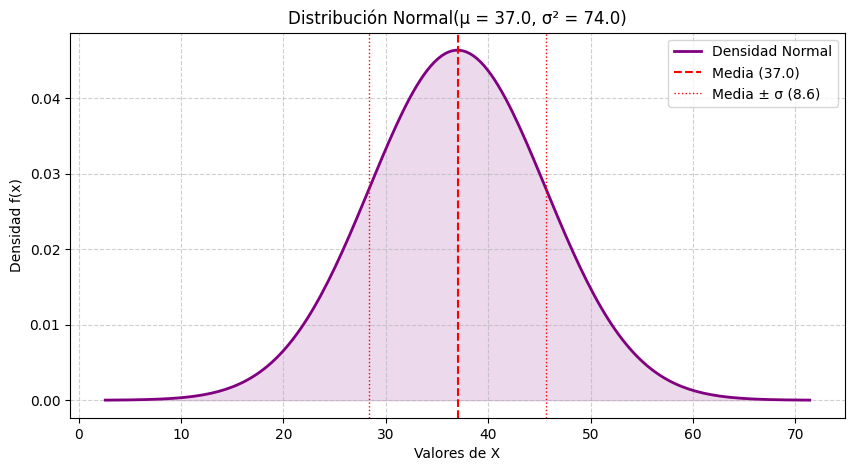

In [74]:
print("\n--- 4. VISUALIZACIÓN MEDIANTE MENSAJES POLIMÓRFICOS ---")
variable_resultante.grafica_densidad(color='purple', color2='red')